# RL Agent Comparison Analysis

Compares fixed dispatching-rule baselines, the random agent, default Q-learning, and the best optimized Q-learning Stage-2 candidate. Switch `USE_HPC` in the configuration cell when final results are available.

In [2]:
from pathlib import Path
import json, math, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass
sns.set_context("notebook")
pd.set_option("display.max_columns", 100)

In [3]:
USE_HPC = True
RL_RESULTS_DIR = Path("rl_results_final_10000_hpc") if USE_HPC else Path("rl_results_test")
TUNING_ROOT = Path("rl_tuning_hpc_100") if USE_HPC else Path("rl_tuning_laptop")
ROLLING_WINDOW = 50
BASELINE_ORDER = ["FIFO", "EDD", "Longest Waiting Time", "Highest Lateness Risk"]
STRATEGY_ORDER = [*BASELINE_ORDER, "Random Agent", "Q-Learning Default", "Q-Learning Optimized"]
ACTION_LABELS = {
    "action_0_count": "FIFO",
    "action_1_count": "EDD",
    "action_2_count": "Longest Waiting Time",
    "action_3_count": "Highest Lateness Risk",
}
NUMERIC_COLUMNS = ["episode", "replication", "total_reward", "late_order_fraction", "time_in_system_mean", "wip_mean", "best_total_reward_so_far", *ACTION_LABELS.keys()]

## Helpers

In [4]:
def warn(message: str) -> None:
    warnings.warn(message, stacklevel=2)
    print(f"WARNING: {message}")

def read_csv_if_exists(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        warn(f"Missing CSV: {path}")
        return pd.DataFrame()
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as exc:
        warn(f"Could not read {path}: {exc}")
        return pd.DataFrame()

def read_json_if_exists(path: Path) -> dict:
    if not path.exists():
        warn(f"Missing JSON: {path}")
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        warn(f"Could not read {path}: {exc}")
        return {}

def empty_plot_message(ax, message: str) -> None:
    ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

def valid_rows(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    if "error" in out.columns:
        out = out[out["error"].fillna("").astype(str).str.len() == 0].copy()
    return out

def coerce_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out

def stage2_dir(root: Path) -> Path:
    return root / "stage2" if (root / "stage2").exists() else root

def candidate_dir_from_row(row, root: Path) -> Path | None:
    data = dict(row)
    raw = data.get("candidate_dir")
    if raw is not None and not pd.isna(raw):
        path = Path(str(raw))
        if path.exists(): return path
        fallback = stage2_dir(root) / path.name
        if fallback.exists(): return fallback
    rank, trial = data.get("candidate_rank"), data.get("source_trial_index")
    if rank is not None and trial is not None and not pd.isna(rank) and not pd.isna(trial):
        path = stage2_dir(root) / f"candidate_rank_{int(rank):02d}_trial_{int(trial):03d}"
        if path.exists(): return path
    return None

In [5]:
def load_stage2_candidates(root: Path = TUNING_ROOT) -> pd.DataFrame:
    for path in [stage2_dir(root) / "stage2_candidates.csv", root / "stage2_candidates.csv"]:
        if path.exists():
            df = read_csv_if_exists(path)
            if not df.empty:
                return coerce_numeric(df, ["candidate_rank", "source_trial_index", "objective_mean", "total_reward_mean"])
    rows = []
    for cdir in sorted(stage2_dir(root).glob("candidate_rank_*_trial_*")):
        summary = read_json_if_exists(cdir / "candidate_summary.json")
        if summary:
            row = {"candidate_rank": summary.get("candidate_rank"), "source_trial_index": summary.get("source_trial_index"), "objective_mean": summary.get("objective_mean"), "total_reward_mean": summary.get("total_reward_mean"), "late_order_fraction_mean": summary.get("late_order_fraction_mean"), "candidate_dir": str(cdir)}
            row.update(summary.get("parameters", {}))
            rows.append(row)
    if rows:
        return coerce_numeric(pd.DataFrame(rows), ["candidate_rank", "source_trial_index", "objective_mean", "total_reward_mean"])
    warn(f"No Stage-2 candidates found under {root}")
    return pd.DataFrame()

def load_best_stage2_candidate(root: Path = TUNING_ROOT):
    for path in [stage2_dir(root) / "stage2_best_candidate.json", root / "stage2_best_candidate.json"]:
        payload = read_json_if_exists(path)
        candidate = payload.get("best_candidate") if isinstance(payload, dict) else None
        if candidate:
            row = pd.Series(candidate)
            return row, candidate_dir_from_row(row, root)
    candidates = load_stage2_candidates(root)
    if candidates.empty: return None, None
    col = "objective_mean" if "objective_mean" in candidates.columns else "total_reward_mean"
    best = candidates.sort_values(col, ascending=(col == "objective_mean")).iloc[0]
    return best, candidate_dir_from_row(best, root)

def load_candidate_csv(candidate_path: Path | None, file_name: str) -> pd.DataFrame:
    if candidate_path is None:
        warn(f"No Stage-2 best candidate directory available for {file_name}")
        return pd.DataFrame()
    return read_csv_if_exists(candidate_path / file_name)

## Load Data

In [6]:
baselines = coerce_numeric(valid_rows(read_csv_if_exists(RL_RESULTS_DIR / "baselines.csv")), NUMERIC_COLUMNS)
random_eval = coerce_numeric(valid_rows(read_csv_if_exists(RL_RESULTS_DIR / "random_agent.csv")), NUMERIC_COLUMNS)
q_train = coerce_numeric(valid_rows(read_csv_if_exists(RL_RESULTS_DIR / "q_learning_training.csv")), NUMERIC_COLUMNS)
q_eval = coerce_numeric(valid_rows(read_csv_if_exists(RL_RESULTS_DIR / "q_learning_evaluation.csv")), NUMERIC_COLUMNS)
best_stage2_row, best_stage2_path = load_best_stage2_candidate(TUNING_ROOT)
optimized_train = coerce_numeric(valid_rows(load_candidate_csv(best_stage2_path, "training.csv")), NUMERIC_COLUMNS)
optimized_eval = coerce_numeric(valid_rows(load_candidate_csv(best_stage2_path, "evaluation.csv")), NUMERIC_COLUMNS)
if best_stage2_row is not None:
    print("Selected optimized Stage-2 candidate:")
    display(pd.DataFrame([best_stage2_row]))
    print(f"Candidate directory: {best_stage2_path}")
display(pd.DataFrame([
    {"source":"baselines", "path":RL_RESULTS_DIR / "baselines.csv", "rows":len(baselines)},
    {"source":"random_agent", "path":RL_RESULTS_DIR / "random_agent.csv", "rows":len(random_eval)},
    {"source":"q_learning_training", "path":RL_RESULTS_DIR / "q_learning_training.csv", "rows":len(q_train)},
    {"source":"q_learning_evaluation", "path":RL_RESULTS_DIR / "q_learning_evaluation.csv", "rows":len(q_eval)},
    {"source":"optimized_training", "path":(best_stage2_path / "training.csv") if best_stage2_path else None, "rows":len(optimized_train)},
    {"source":"optimized_evaluation", "path":(best_stage2_path / "evaluation.csv") if best_stage2_path else None, "rows":len(optimized_eval)},
]))

Selected optimized Stage-2 candidate:


,candidate_rank,source_trial_index,alpha,gamma,target_final_epsilon,risk_t1,risk_window,epsilon_min,epsilon_decay,stage1_objective_mean,stage1_total_reward_mean,objective_mean,objective_std,total_reward_mean,total_reward_std,late_order_fraction_mean,n_valid_replications,best_training_reward,best_training_episode,best_training_seed,best_evaluation_reward,best_evaluation_replication,best_evaluation_seed,q_table_size,candidate_dir,q_table_path
0,2,51,0.005,0.2,0.02,174.225153,120.0,0.02,0.999609,-300.2,300.2,-356.833333,319.176428,356.833333,319.176428,0.420611,30,1386.0,7830,8042345,1183.0,26,338345,26,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...


Candidate directory: rl_tuning_hpc_100\stage2\candidate_rank_02_trial_051


,source,path,rows
0,baselines,rl_results_final_10000_hpc\baselines.csv,120
1,random_agent,rl_results_final_10000_hpc\random_agent.csv,30
2,q_learning_training,rl_results_final_10000_hpc\q_learning_training...,10000
3,q_learning_evaluation,rl_results_final_10000_hpc\q_learning_evaluati...,30
4,optimized_training,rl_tuning_hpc_100\stage2\candidate_rank_02_tri...,10000
5,optimized_evaluation,rl_tuning_hpc_100\stage2\candidate_rank_02_tri...,30


In [7]:
def add_strategy(df, strategy):
    if df.empty: return pd.DataFrame()
    out = df.copy(); out["strategy"] = strategy; return out
frames = []
if not baselines.empty and "baseline_rule" in baselines.columns:
    b = baselines.copy(); b["strategy"] = b["baseline_rule"].fillna("Baseline"); frames.append(b)
frames += [add_strategy(random_eval, "Random Agent"), add_strategy(q_eval, "Q-Learning Default"), add_strategy(optimized_eval, "Q-Learning Optimized")]
evaluation_results = pd.concat([f for f in frames if not f.empty], ignore_index=True, sort=False) if any(not f.empty for f in frames) else pd.DataFrame()
if not evaluation_results.empty:
    evaluation_results["strategy"] = pd.Categorical(evaluation_results["strategy"], categories=STRATEGY_ORDER, ordered=True)
    evaluation_results = evaluation_results.sort_values("strategy")
display(evaluation_results.head())
print(f"Evaluation rows loaded: {len(evaluation_results)}")

,label,error,replication,eval_seed,episode,baseline_rule,action_random_seed,q_table_size,best_total_reward_so_far,random_seed,run_duration,due_date_lower_bound,due_date_upper_bound,rate_multiplier,risk_t1,risk_window,risk_t2,agent_type,training,fixed_action,msg,n_orders_created,n_orders_completed,n_orders_in_date,n_orders_late,late_order_fraction,time_in_system_mean,time_in_system_std,time_in_system_min,time_in_system_max,wip_mean,wip_max,total_reward,n_eval_failures,n_decision_points,action_0_count,action_1_count,action_2_count,action_3_count,epsilon,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,strategy,objective_value,alpha,gamma,target_final_epsilon,epsilon_decay,epsilon_min
0,NaN,NaN,0,312345,NaN,FIFO,NaN,NaN,NaN,312345,1440.0,4,8,0.9,175.214912,120.0,295.214912,baseline,False,0.0,simulation ended,487,271,166,105,0.387454,310.321778,181.129609,8.950990,909.783566,109.325478,217,508.0,34,350,350,0,0,0,NaN,1,1,1,1,1,1,1,FIFO,NaN,NaN,NaN,NaN,NaN,NaN
29,NaN,NaN,29,341345,NaN,FIFO,NaN,NaN,NaN,341345,1440.0,4,8,0.9,175.214912,120.0,295.214912,baseline,False,0.0,simulation ended,572,286,144,142,0.496503,359.854618,200.963678,12.492308,1077.492801,146.044263,287,-76.0,32,360,360,0,0,0,NaN,1,1,1,1,1,1,1,FIFO,NaN,NaN,NaN,NaN,NaN,NaN
28,NaN,NaN,28,340345,NaN,FIFO,NaN,NaN,NaN,340345,1440.0,4,8,0.9,175.214912,120.0,295.214912,baseline,False,0.0,simulation ended,570,290,156,134,0.462069,348.215776,190.984779,11.742515,1012.425060,135.130954,280,154.0,22,357,357,0,0,0,NaN,1,1,1,1,1,1,1,FIFO,NaN,NaN,NaN,NaN,NaN,NaN
27,NaN,NaN,27,339345,NaN,FIFO,NaN,NaN,NaN,339345,1440.0,4,8,0.9,175.214912,120.0,295.214912,baseline,False,0.0,simulation ended,556,280,147,133,0.475000,334.686510,204.751283,18.866435,1168.488655,132.878569,278,50.0,30,358,358,0,0,0,NaN,1,1,1,1,1,1,1,FIFO,NaN,NaN,NaN,NaN,NaN,NaN
26,NaN,NaN,26,338345,NaN,FIFO,NaN,NaN,NaN,338345,1440.0,4,8,0.9,175.214912,120.0,295.214912,baseline,False,0.0,simulation ended,505,283,184,99,0.349823,271.403750,165.612984,12.919052,819.594632,101.014745,223,763.0,29,358,358,0,0,0,NaN,1,1,1,1,1,1,1,FIFO,NaN,NaN,NaN,NaN,NaN,NaN


Evaluation rows loaded: 210


## Training Curve

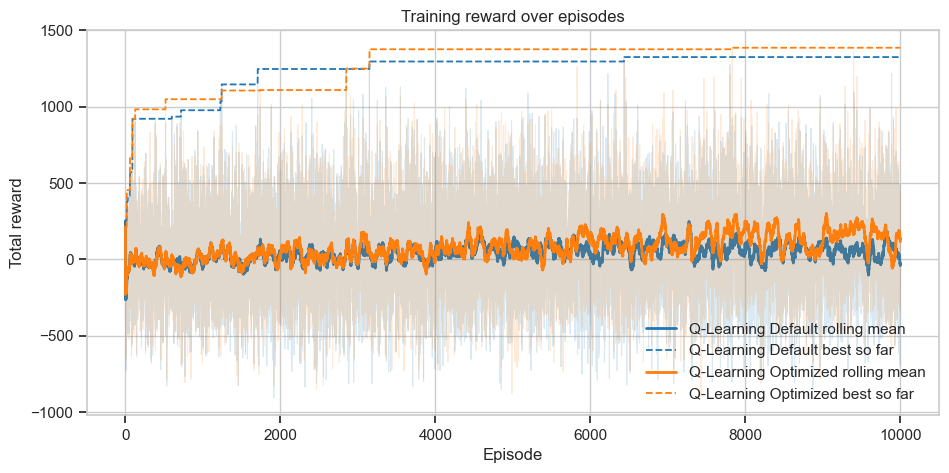

In [8]:
def plot_training_curve(ax, df, label, color):
    if df.empty or not {"episode", "total_reward"}.issubset(df.columns): return
    cols = ["episode", "total_reward"] + (["best_total_reward_so_far"] if "best_total_reward_so_far" in df.columns else [])
    data = df[cols].dropna(subset=["episode", "total_reward"]).sort_values("episode")
    if data.empty: return
    window = max(1, min(ROLLING_WINDOW, max(1, len(data)//5)))
    ax.plot(data["episode"], data["total_reward"], color=color, alpha=0.16, linewidth=0.8)
    ax.plot(data["episode"], data["total_reward"].rolling(window, min_periods=1).mean(), color=color, linewidth=2, label=f"{label} rolling mean")
    if "best_total_reward_so_far" in data.columns and data["best_total_reward_so_far"].notna().any():
        ax.plot(data["episode"], data["best_total_reward_so_far"], color=color, linestyle="--", linewidth=1.3, label=f"{label} best so far")
fig, ax = plt.subplots(figsize=(11,5))
plot_training_curve(ax, q_train, "Q-Learning Default", "tab:blue")
plot_training_curve(ax, optimized_train, "Q-Learning Optimized", "tab:orange")
if not ax.lines: empty_plot_message(ax, "No Q-learning training data available.")
else:
    ax.set_title("Training reward over episodes"); ax.set_xlabel("Episode"); ax.set_ylabel("Total reward"); ax.legend()
plt.show()

## Evaluation Reward Distribution

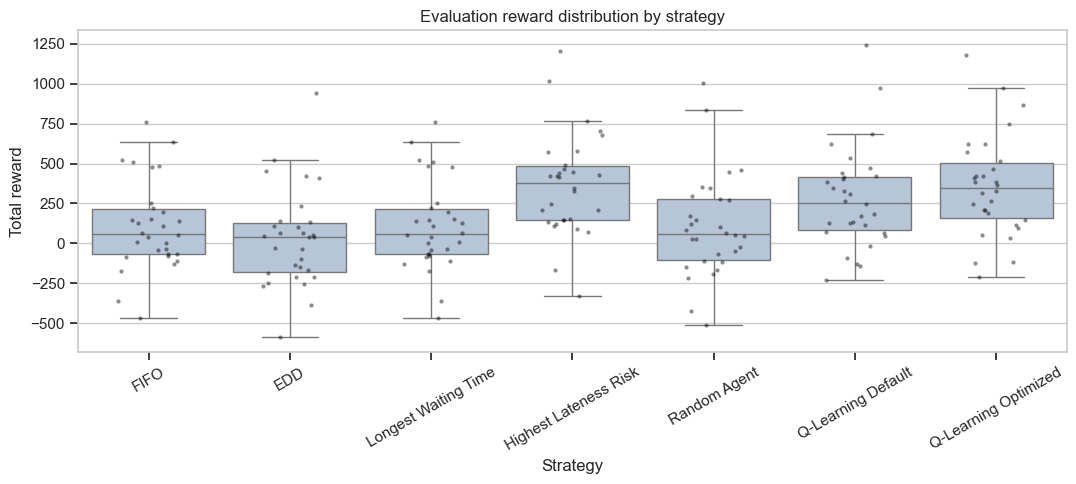

In [9]:
fig, ax = plt.subplots(figsize=(11,5))
if evaluation_results.empty or "total_reward" not in evaluation_results.columns:
    empty_plot_message(ax, "No evaluation reward data available.")
else:
    sns.boxplot(data=evaluation_results, x="strategy", y="total_reward", ax=ax, color="lightsteelblue", showfliers=False)
    sns.stripplot(data=evaluation_results, x="strategy", y="total_reward", ax=ax, color="black", alpha=0.45, size=3, jitter=0.22)
    ax.set_title("Evaluation reward distribution by strategy"); ax.set_xlabel("Strategy"); ax.set_ylabel("Total reward"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Mean Reward with 95% Confidence Interval

,strategy,mean,std,count,sem,ci95
0,FIFO,109.500000,282.494278,30,51.576163,101.089279
1,EDD,27.500000,306.285167,30,55.919765,109.602739
2,Longest Waiting Time,109.500000,282.494278,30,51.576163,101.089279
3,Highest Lateness Risk,362.833333,318.980821,30,58.237664,114.145821
4,Random Agent,104.166667,320.621926,30,58.537287,114.733083
5,Q-Learning Default,284.166667,320.725157,30,58.556134,114.770024
6,Q-Learning Optimized,356.833333,319.176428,30,58.273376,114.215818


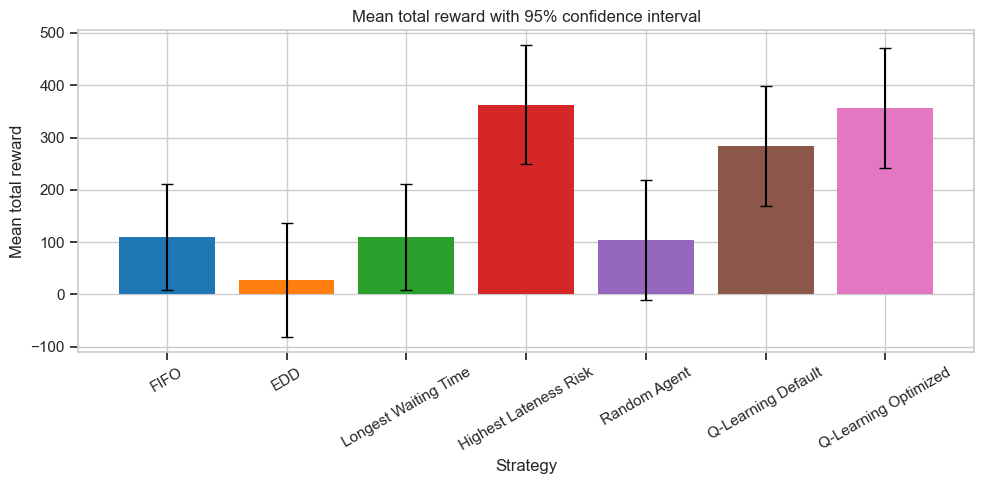

In [10]:
def mean_ci_summary(df, group_col, value_col):
    if df.empty or value_col not in df.columns: return pd.DataFrame()
    s = df.dropna(subset=[value_col]).groupby(group_col, observed=False)[value_col].agg(["mean", "std", "count"]).reset_index()
    s["sem"] = s["std"] / np.sqrt(s["count"].clip(lower=1)); s["ci95"] = 1.96 * s["sem"]; s.loc[s["count"] <= 1, "ci95"] = 0.0
    return s
reward_summary = mean_ci_summary(evaluation_results, "strategy", "total_reward")
display(reward_summary)
fig, ax = plt.subplots(figsize=(10,5))
if reward_summary.empty: empty_plot_message(ax, "No reward summary available.")
else:
    ax.bar(reward_summary["strategy"].astype(str), reward_summary["mean"], yerr=reward_summary["ci95"], capsize=4, color=sns.color_palette("tab10", len(reward_summary)))
    ax.set_title("Mean total reward with 95% confidence interval"); ax.set_xlabel("Strategy"); ax.set_ylabel("Mean total reward"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Late Order Fraction

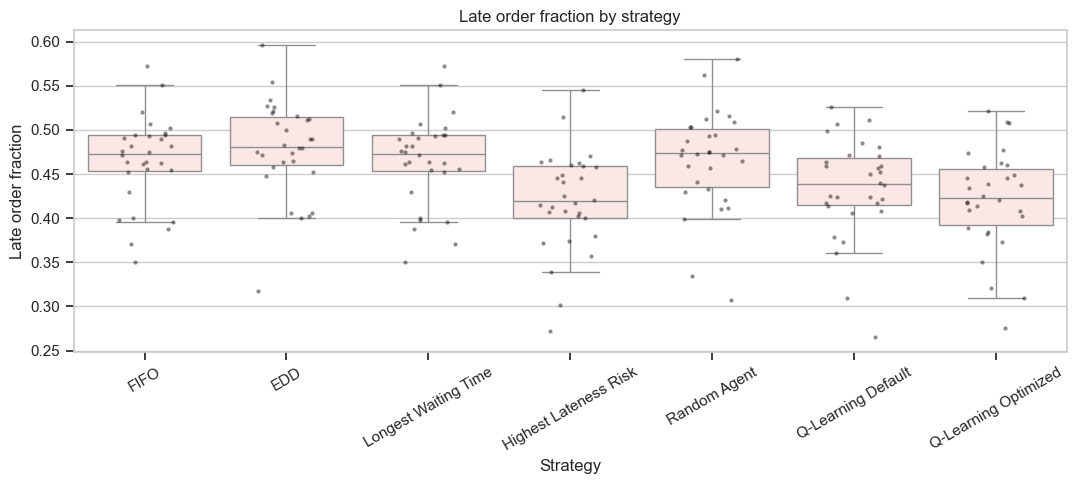

In [11]:
fig, ax = plt.subplots(figsize=(11,5))
if evaluation_results.empty or "late_order_fraction" not in evaluation_results.columns:
    empty_plot_message(ax, "No late-order-fraction data available.")
else:
    sns.boxplot(data=evaluation_results, x="strategy", y="late_order_fraction", ax=ax, color="mistyrose", showfliers=False)
    sns.stripplot(data=evaluation_results, x="strategy", y="late_order_fraction", ax=ax, color="black", alpha=0.45, size=3, jitter=0.22)
    ax.set_title("Late order fraction by strategy"); ax.set_xlabel("Strategy"); ax.set_ylabel("Late order fraction"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Time in System / WIP Trade-Off

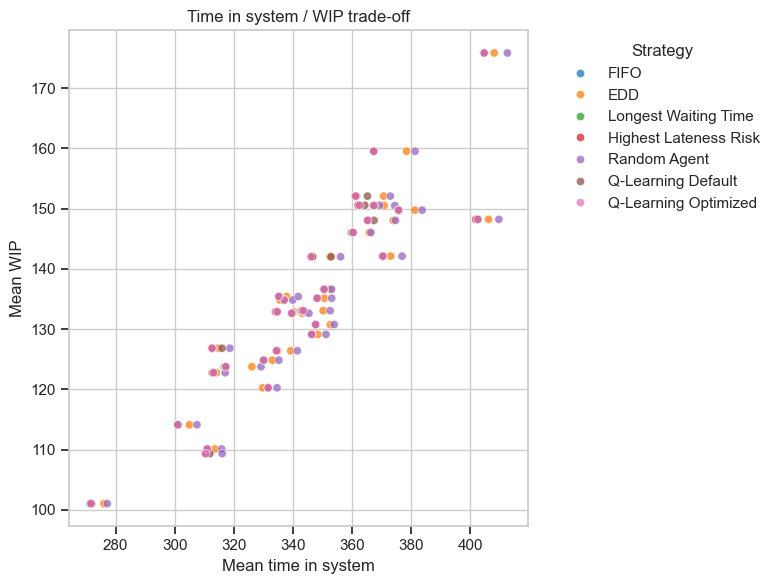

In [12]:
fig, ax = plt.subplots(figsize=(8,6))
if evaluation_results.empty or not {"time_in_system_mean", "wip_mean", "strategy"}.issubset(evaluation_results.columns):
    empty_plot_message(ax, "No time-in-system / WIP data available.")
else:
    sns.scatterplot(data=evaluation_results, x="time_in_system_mean", y="wip_mean", hue="strategy", ax=ax, alpha=0.75)
    ax.set_title("Time in system / WIP trade-off"); ax.set_xlabel("Mean time in system"); ax.set_ylabel("Mean WIP"); ax.legend(title="Strategy", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout(); plt.show()

## Action Usage of Q-Learning Agents

,agent,action,share
0,Q-Learning Default,FIFO,0.243006
1,Q-Learning Default,EDD,0.140264
2,Q-Learning Default,Longest Waiting Time,0.367924
3,Q-Learning Default,Highest Lateness Risk,0.248807
4,Q-Learning Optimized,FIFO,0.648919
5,Q-Learning Optimized,EDD,0.024984
6,Q-Learning Optimized,Longest Waiting Time,0.058669
7,Q-Learning Optimized,Highest Lateness Risk,0.267428


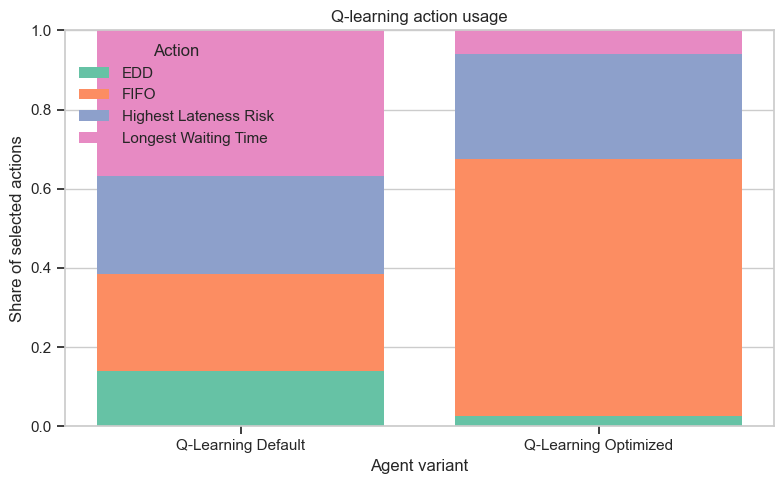

In [13]:
def action_usage_frame(named_frames):
    rows=[]
    for agent, df in named_frames.items():
        cols=[c for c in ACTION_LABELS if c in df.columns]
        if df.empty or not cols: continue
        counts=df[cols].apply(pd.to_numeric, errors="coerce").sum(); total=counts.sum()
        if total <= 0 or pd.isna(total): continue
        rows += [{"agent":agent, "action":ACTION_LABELS[col], "share":counts[col]/total} for col in cols]
    return pd.DataFrame(rows)
usage = action_usage_frame({"Q-Learning Default": q_eval, "Q-Learning Optimized": optimized_eval})
display(usage)
fig, ax = plt.subplots(figsize=(8,5))
if usage.empty: empty_plot_message(ax, "No Q-learning action usage data available.")
else:
    pivot = usage.pivot(index="agent", columns="action", values="share").fillna(0)
    bottom = np.zeros(len(pivot))
    for color, action in zip(sns.color_palette("Set2", len(pivot.columns)), pivot.columns):
        ax.bar(pivot.index, pivot[action], bottom=bottom, label=action, color=color); bottom += pivot[action].to_numpy()
    ax.set_title("Q-learning action usage"); ax.set_xlabel("Agent variant"); ax.set_ylabel("Share of selected actions"); ax.set_ylim(0,1); ax.legend(title="Action")
plt.tight_layout(); plt.show()

## Reward vs. Late Fraction

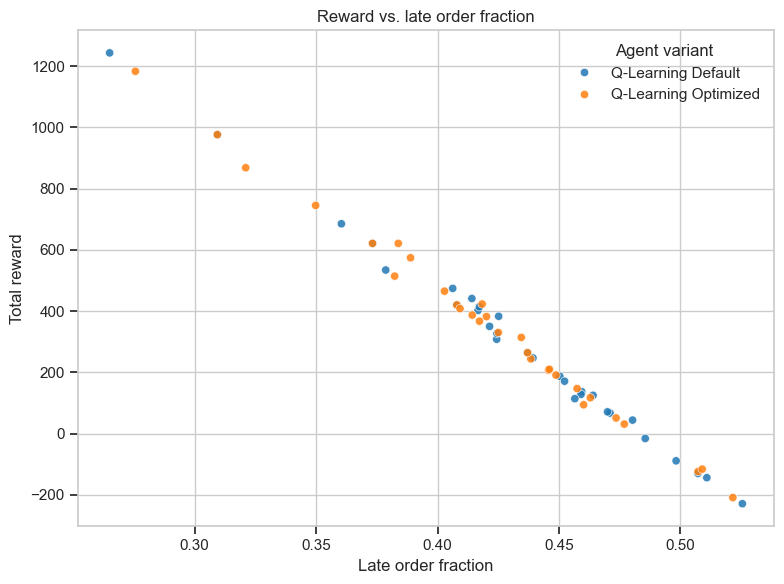

In [14]:
frames=[]
for label, df in {"Q-Learning Default": q_eval, "Q-Learning Optimized": optimized_eval}.items():
    if not df.empty:
        temp=df.copy(); temp["agent_variant"]=label; frames.append(temp)
q_eval_compare = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()
fig, ax = plt.subplots(figsize=(8,6))
if q_eval_compare.empty or not {"late_order_fraction", "total_reward"}.issubset(q_eval_compare.columns):
    empty_plot_message(ax, "No Q-learning reward/late-fraction data available.")
else:
    sns.scatterplot(data=q_eval_compare, x="late_order_fraction", y="total_reward", hue="agent_variant", ax=ax, alpha=0.85)
    ax.set_title("Reward vs. late order fraction"); ax.set_xlabel("Late order fraction"); ax.set_ylabel("Total reward"); ax.legend(title="Agent variant")
plt.tight_layout(); plt.show()